In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [4]:
from imblearn.over_sampling import SMOTE

In [5]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv("customer_churn_dataset.csv")

In [8]:
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.00,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.00,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.00,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.00,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.00,20.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
440828,449995.0,42.0,Male,54.0,15.0,1.0,3.0,Premium,Annual,716.38,8.0,0.0
440829,449996.0,25.0,Female,8.0,13.0,1.0,20.0,Premium,Annual,745.38,2.0,0.0
440830,449997.0,26.0,Male,35.0,27.0,1.0,5.0,Standard,Quarterly,977.31,9.0,0.0
440831,449998.0,28.0,Male,55.0,14.0,2.0,0.0,Standard,Quarterly,602.55,2.0,0.0


In [9]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [10]:
df = df.dropna()
df.shape

(440832, 12)

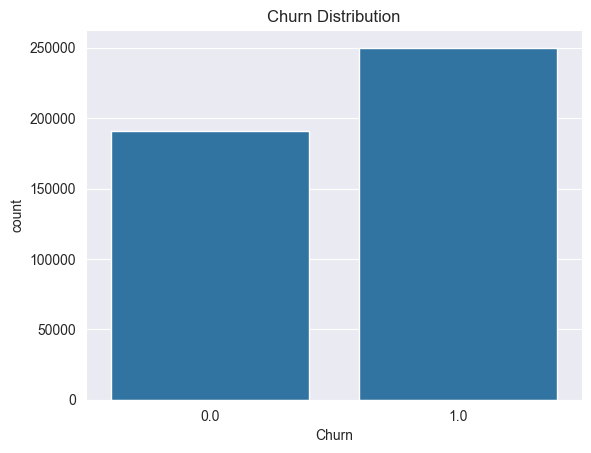

In [11]:
plt.figure()
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

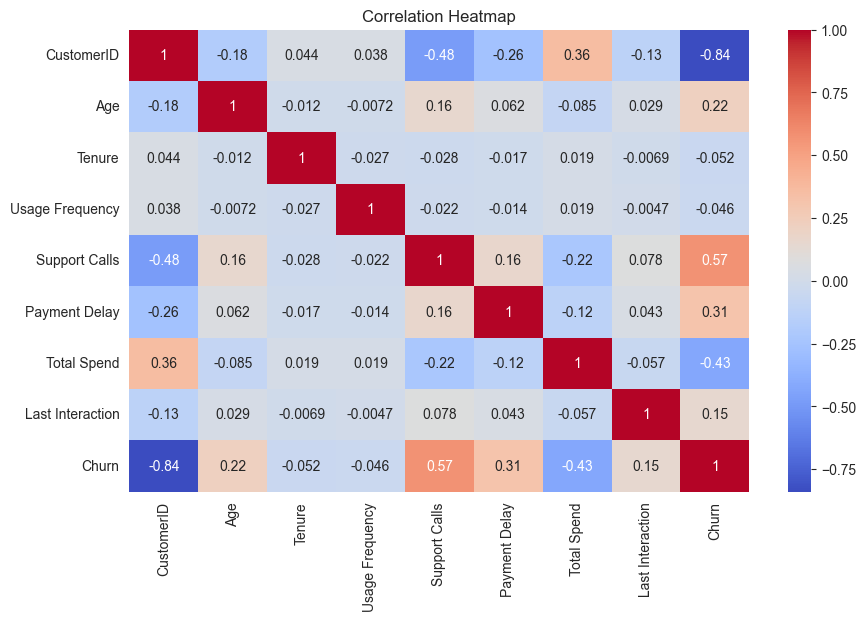

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=["int64", "float64"]).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

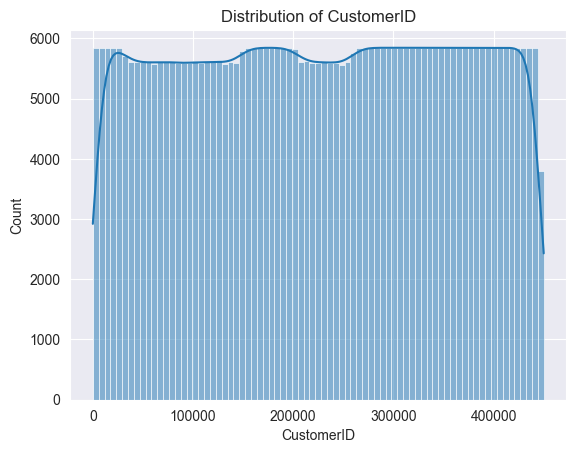

In [13]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
plt.figure()
sns.histplot(df[num_cols[0]], kde=True)
plt.title(f"Distribution of {num_cols[0]}")
plt.show()

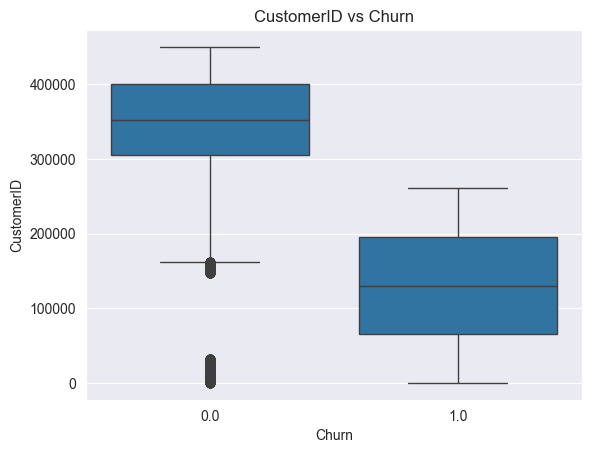

In [14]:
plt.figure()
sns.boxplot(x="Churn", y=num_cols[0], data=df)
plt.title(f"{num_cols[0]} vs Churn")
plt.show()

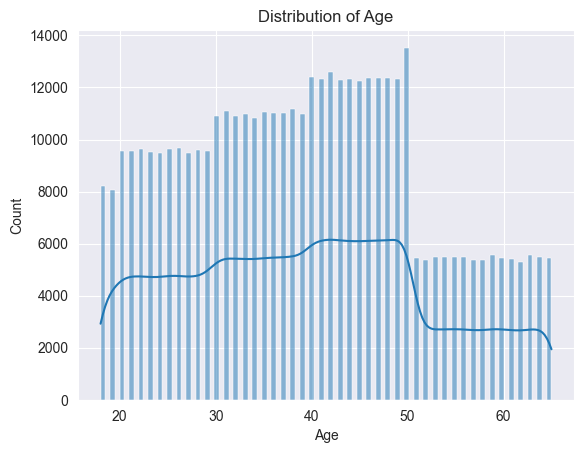

In [15]:
if len(num_cols) > 1:
    plt.figure()
    sns.histplot(df[num_cols[1]], kde=True)
    plt.title(f"Distribution of {num_cols[1]}")
    plt.show()

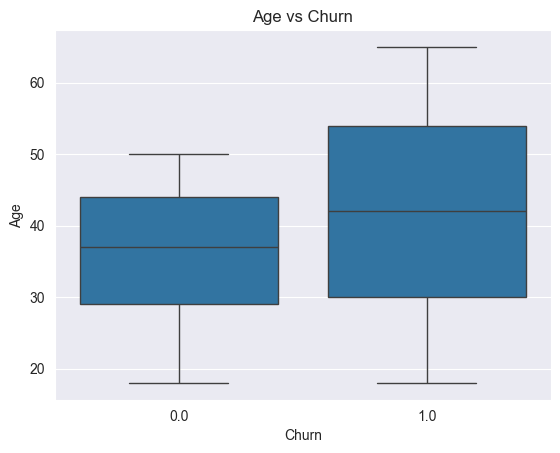

In [16]:
if len(num_cols) > 1:
    plt.figure()
    sns.boxplot(x="Churn", y=num_cols[1], data=df)
    plt.title(f"{num_cols[1]} vs Churn")
    plt.show()

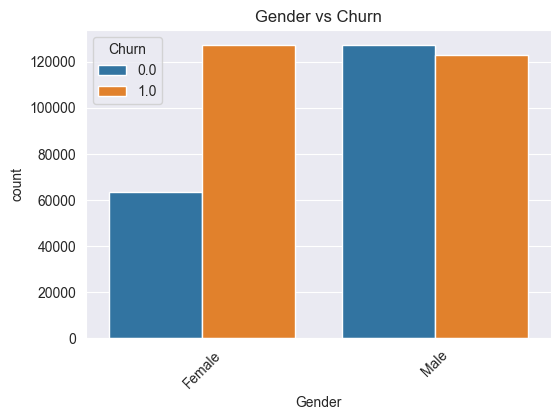

In [17]:
cat_cols = df.select_dtypes(include=["object"]).columns
plt.figure(figsize=(6, 4))
sns.countplot(x=cat_cols[0], hue="Churn", data=df)
plt.title(f"{cat_cols[0]} vs Churn")
plt.xticks(rotation=45)
plt.show()

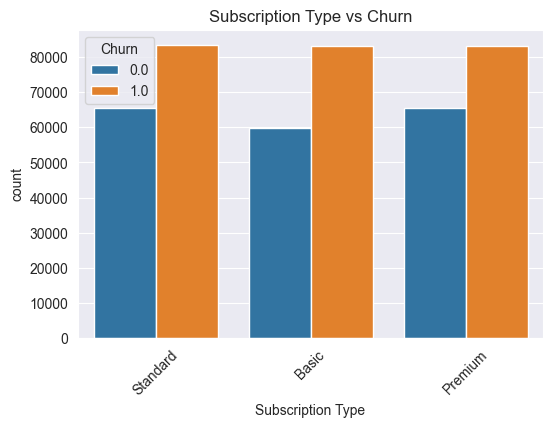

In [18]:
if len(cat_cols) > 1:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=cat_cols[1], hue="Churn", data=df)
    plt.title(f"{cat_cols[1]} vs Churn")
    plt.xticks(rotation=45)
    plt.show()

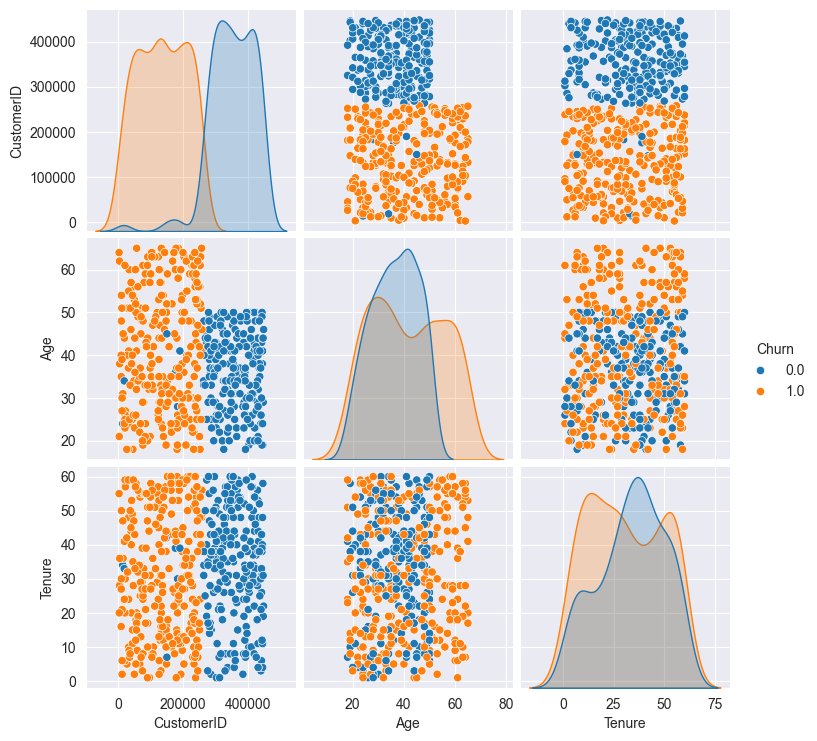

In [19]:
sample_df = df.sample(min(500, len(df)), random_state=42)
sns.pairplot(sample_df, hue="Churn", vars=num_cols[:3])
plt.show()

Key Insights from Exploratory Data Analysis:

- Churn class imbalance observed.
- Certain categorical features show strong separation with churn.
- Some numerical features show skewness and require scaling.

In [32]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [33]:
X.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0


In [ ]:
numerical_cols, categorical_cols

In [ ]:
X.shape

In [ ]:
X.info()

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [38]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

In [43]:
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))
])

In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [45]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape

(352665, 15)

In [46]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_processed, y_train
)

In [47]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC()
}

In [48]:
results = []

In [49]:
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_pred = model.predict(X_test_processed)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

In [50]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.979085,0.986169,0.97682,0.981472
1,Random Forest,0.999569,0.999320,0.99992,0.999620
2,SVM,0.994318,0.994288,0.99570,0.994994


In [51]:
best_model = results_df.sort_values("F1-Score", ascending=False).iloc[0]
best_model

Model        Random Forest
Accuracy          0.999569
Precision          0.99932
Recall             0.99992
F1-Score           0.99962
Name: 1, dtype: object